# 1. Import Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter
import io

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

# 2. Load Dataset

In [3]:
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data()

# 3. Data preprocessing

## 3.1 Normalize and add dimensions \ channel

In [4]:
# Normalize images to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## 3.2 apply gaussian blur to the image

In [5]:
def apply_gaussian_blur(image):
    """
    Apply Gaussian blur to a 28x28 grayscale image.
    """
    img = Image.fromarray((image.squeeze() * 255).astype(np.uint8))

    radius = np.random.uniform(0.5, 2.0)

    img = img.filter(
        ImageFilter.GaussianBlur(radius=radius)
    )

    img = np.array(img).astype("float32") / 255.0

    return np.expand_dims(img, axis=-1)

## 3.3 Motion like blur

In [6]:
def apply_motion_blur(image):
    """
    Approximate motion blur using directional convolution.
    """

    image = image.astype("float32")

    kernel_size = np.random.choice([3, 5, 7])

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)

    direction = np.random.choice(["horizontal", "vertical"])

    if direction == "horizontal":
        kernel[kernel_size // 2, :] = 1.0 / kernel_size
    else:
        kernel[:, kernel_size // 2] = 1.0 / kernel_size

    image_tensor = tf.convert_to_tensor(image[None, ...])

    kernel = kernel[:, :, None, None]

    blurred = tf.nn.depthwise_conv2d(
        image_tensor,
        kernel,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )

    return blurred.numpy()[0]

## 3.4 Add gaussian noise

In [7]:
def add_gaussian_noise(image):

    noise_level = np.random.uniform(0.05, 0.30)

    noise = np.random.normal(
        loc=0.0,
        scale=noise_level,
        size=image.shape
    )

    noisy_image = image + noise

    return np.clip(noisy_image, 0.0, 1.0)

## 3.5 Add Salt and pepper noise

In [ ]:
def add_salt_pepper_noise(image):

    noisy_image = image.copy()

    probability = np.random.uniform(0.01, 0.08)

    random_values = np.random.random(image.shape[:2])

    noisy_image[random_values < probability / 2] = 0

    noisy_image[
        (random_values >= probability / 2) &
        (random_values < probability)
    ] = 1

    return noisy_image

## 3.6 Simulate compressed image

In [9]:
def apply_compression(image):

    img = Image.fromarray(
        (image.squeeze() * 255).astype(np.uint8)
    )

    buffer = io.BytesIO()

    quality = np.random.randint(10, 50)

    img.save(
        buffer,
        format="JPEG",
        quality=quality
    )

    buffer.seek(0)

    compressed_img = Image.open(buffer)

    compressed_img = np.array(
        compressed_img
    ).astype("float32") / 255.0

    return np.expand_dims(compressed_img, axis=-1)

## 3.7 Creating general degradation function

In [10]:
def degrade_image(image):

    degraded = image.copy()

    degradation_type = np.random.choice([
        "gaussian_blur",
        "motion_blur",
        "gaussian_noise",
        "salt_pepper",
        "compression",
        "mixed"
    ])

    if degradation_type == "gaussian_blur":

        degraded = apply_gaussian_blur(degraded)

    elif degradation_type == "motion_blur":

        degraded = apply_motion_blur(degraded)

    elif degradation_type == "gaussian_noise":

        degraded = add_gaussian_noise(degraded)

    elif degradation_type == "salt_pepper":

        degraded = add_salt_pepper_noise(degraded)

    elif degradation_type == "compression":

        degraded = apply_compression(degraded)

    elif degradation_type == "mixed":

        # Blur
        if np.random.random() < 0.7:
            degraded = apply_gaussian_blur(degraded)

        # Noise
        if np.random.random() < 0.8:
            degraded = add_gaussian_noise(degraded)

        # Salt and pepper
        if np.random.random() < 0.3:
            degraded = add_salt_pepper_noise(degraded)

        # Compression
        if np.random.random() < 0.5:
            degraded = apply_compression(degraded)

    return np.clip(degraded, 0.0, 1.0)

## 3.8 generate degraded training images

In [13]:
num_train = 10000
num_test = 2000

X_train_clean = X_train[:num_train]
X_test_clean = X_test[:num_test]

In [14]:
X_train_degraded = np.array([
    degrade_image(image)
    for image in X_train_clean
])

X_test_degraded = np.array([
    degrade_image(image)
    for image in X_test_clean
])

In [15]:
print(X_train_clean.shape)
print(X_train_degraded.shape)

(10000, 28, 28, 1)
(10000, 28, 28, 1)


## 3.9 vISUALIZE THE DATA

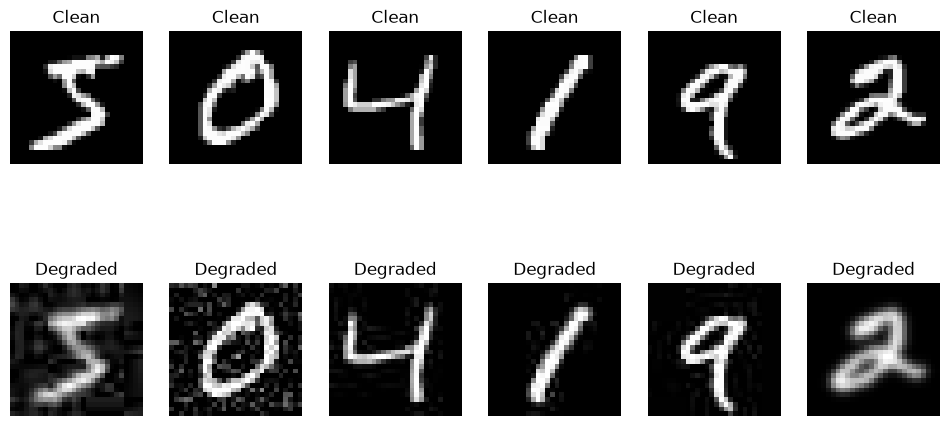

In [16]:
plt.figure(figsize=(12, 6))

for i in range(6):

    # Clean
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train_clean[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Degraded
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_train_degraded[i].squeeze(), cmap="gray")
    plt.title("Degraded")
    plt.axis("off")

plt.show()

# 4. Model Building

In [23]:
model = Sequential()

# =========================
# ENCODER
# =========================

model.add(Conv2D(filters=32,kernel_size=(3, 3),strides=(1, 1),padding="same",activation="relu",input_shape=(28, 28, 1)))

model.add(
    MaxPooling2D(
        pool_size=(2, 2),
        padding="same"
    )
)

model.add(
    Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2, 2),
        padding="same"
    )
)

# =========================
# DECODER
# =========================

model.add(
    Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    UpSampling2D(
        size=(2, 2)
    )
)

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    UpSampling2D(
        size=(2, 2)
    )
)

# =========================
# OUTPUT
# =========================

model.add(
    Conv2D(
        filters=1,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Model compile

In [24]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["accuracy"]
)

# 6. Model training

In [25]:
history = model.fit(
    X_train_degraded,
    X_train_clean,
    epochs=30,
    batch_size=32,
    validation_data=(
        X_test_degraded,
        X_test_clean
    )
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8099 - loss: 0.0253 - val_accuracy: 0.8233 - val_loss: 0.0141
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8125 - loss: 0.0127 - val_accuracy: 0.8234 - val_loss: 0.0114
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8127 - loss: 0.0110 - val_accuracy: 0.8237 - val_loss: 0.0104
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8129 - loss: 0.0101 - val_accuracy: 0.8237 - val_loss: 0.0096
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8130 - loss: 0.0095 - val_accuracy: 0.8236 - val_loss: 0.0093
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8131 - loss: 0.0090 - val_accuracy: 0.8237 - val_loss: 0.0089
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8132 - loss: 0.0087 - val_accuracy: 0.8236 - val_loss: 0.0087
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8133 - loss: 0.0085 - val_accu

# 7. Model prediction

In [26]:
predictions = model.predict(
    X_test_degraded[:10],
    verbose=0
)

# Because final layer is ReLU
predictions = np.clip(
    predictions,
    0.0,
    1.0
)

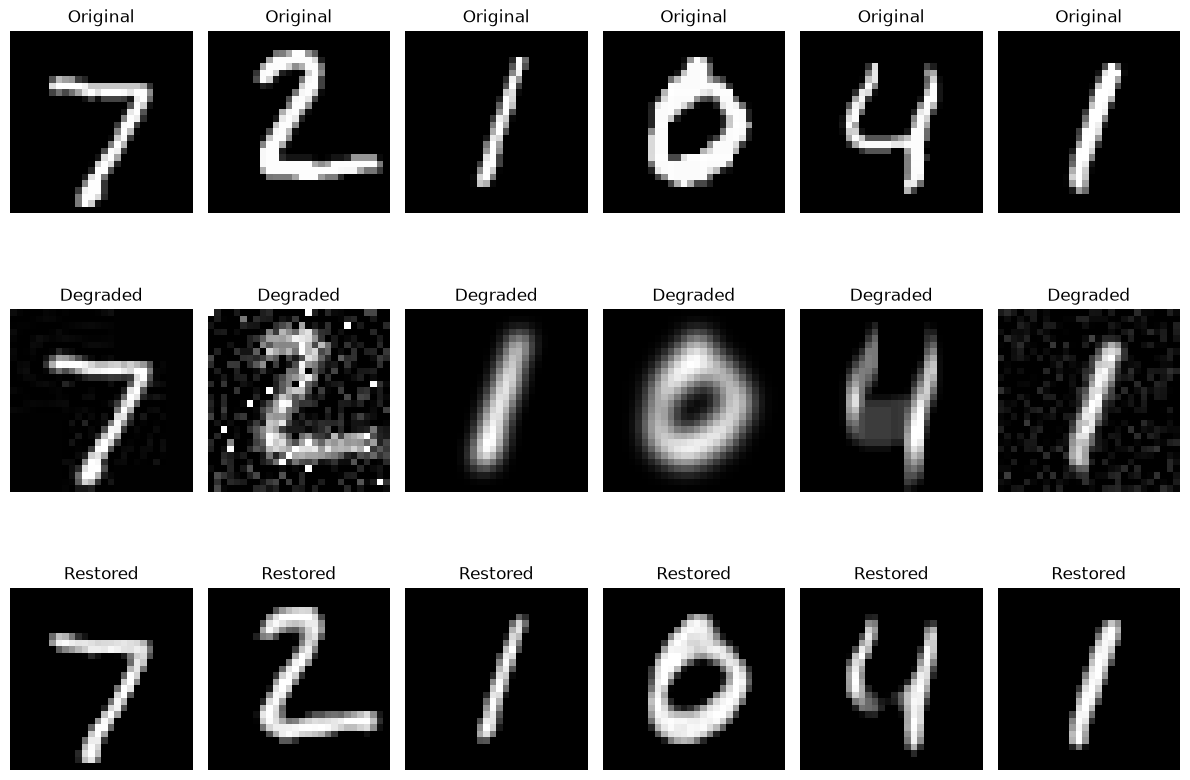

In [27]:
plt.figure(figsize=(12, 9))

for i in range(6):

    # Original
    plt.subplot(3, 6, i + 1)

    plt.imshow(
        X_test_clean[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # Degraded
    plt.subplot(3, 6, i + 7)

    plt.imshow(
        X_test_degraded[i].squeeze(),
        cmap="gray"
    )

    plt.title("Degraded")
    plt.axis("off")

    # Restored
    plt.subplot(3, 6, i + 13)

    plt.imshow(
        predictions[i].squeeze(),
        cmap="gray"
    )

    plt.title("Restored")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Save model

In [28]:
model.save("image_restoration_autoencoder.h5")

# 9. load the model

In [29]:
from tensorflow.keras.models import load_model

restoration_model = load_model(
    "image_restoration_autoencoder.h5",
    compile=False
)

# 10. test an outside image

In [30]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [39]:
img_path = r"C:\Users\varun\OneDrive\Documents\DQL\Deep Learning\autoencoder\X blurimage.jpg"

In [40]:
image = Image.open(img_path)
image = image.convert("L")
image = image.resize((28, 28))
image_array = np.array(image).astype("float32") / 255.0
image_array = np.expand_dims(
    image_array,
    axis=-1
)
image_array = np.expand_dims(
    image_array,
    axis=0
)
print(image_array.shape)

(1, 28, 28, 1)


In [41]:
restored = restoration_model.predict(
    image_array,
    verbose=0
)
# Important because you are using ReLU
restored = np.clip(
    restored,
    0.0,
    1.0
)

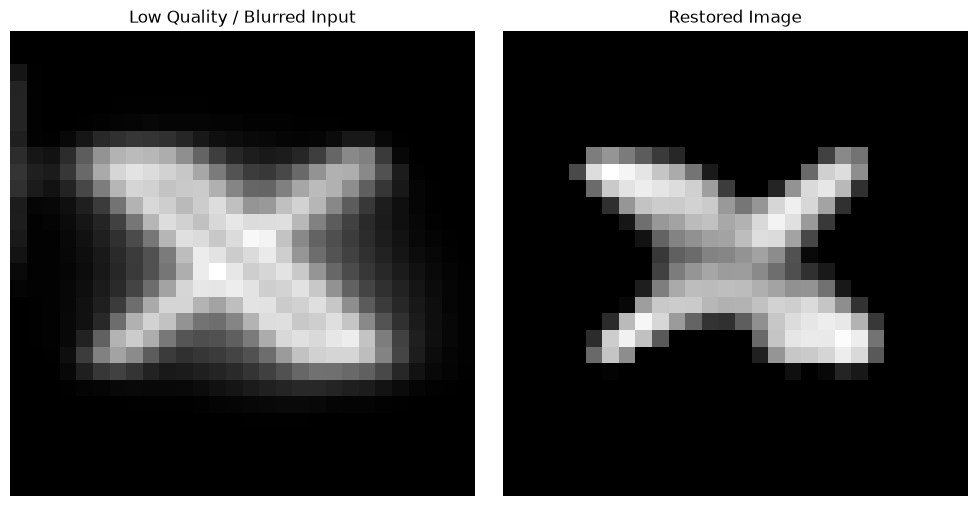

In [42]:
plt.figure(figsize=(10, 5))

# Input
plt.subplot(1, 2, 1)

plt.imshow(
    image_array[0].squeeze(),
    cmap="gray"
)

plt.title("Low Quality / Blurred Input")
plt.axis("off")


# Restored
plt.subplot(1, 2, 2)

plt.imshow(
    restored[0].squeeze(),
    cmap="gray"
)

plt.title("Restored Image")
plt.axis("off")

plt.tight_layout()
plt.show()